
# Jugo – Simple IBCS Dashboard Classifier

This notebook is a **simple binary image classifier**.

Goal:
- **1 = compliant**
- **0 = non-compliant**

This version is intentionally kept simple so the group can:
- understand every step
- test whether the model actually learns the right thing
- avoid unnecessary complexity

We use a **small CNN** instead of a large pretrained model.


## 1. Imports and settings

In [ ]:

import os
import random
from pathlib import Path

import torch
import matplotlib.pyplot as plt
from PIL import Image
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models


# Settings
DATA_DIR = Path("../images_data")
IMG_SIZE = 128
BATCH_SIZE = 8
EPOCHS = 10
LEARNING_RATE = 0.001
#We predefine the seed to make sure test results are reproducable
SEED = 20
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
torch.manual_seed(SEED)

print(f"Using device: {DEVICE}")


Using device: cpu



This notebook assumes your dataset is stored like this:

```text
images_data/
├── compliant/
└── non-compliant/
```


## 2. Dataset class

In [165]:

class DashboardDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.transform = transform
        self.samples = []

        label_map = {
            "compliant": 1,
            "non-compliant": 0,
        }

        valid_extensions = {".png", ".jpg", ".jpeg", ".bmp", ".webp"}

        for folder_name, label in label_map.items():
            folder_path = Path(data_dir) / folder_name

            for file_path in sorted(folder_path.iterdir()):
                if file_path.suffix.lower() in valid_extensions:
                    self.samples.append((file_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_path, label = self.samples[idx]
        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor([label], dtype=torch.float32)
        return image, label


## 3. Image preprocessing

In [166]:

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])


## 4. Load dataset and split into train / validation / test

In [167]:

dataset = DashboardDataset(DATA_DIR, transform=transform)

train_size = int(0.65 * len(dataset))
val_size = int(0.20 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Total images: {len(dataset)}")
print(f"Train: {len(train_dataset)}")
print(f"Validation: {len(val_dataset)}")
print(f"Test: {len(test_dataset)}")


Total images: 40
Train: 26
Validation: 8
Test: 6


## 5. Show a few training images

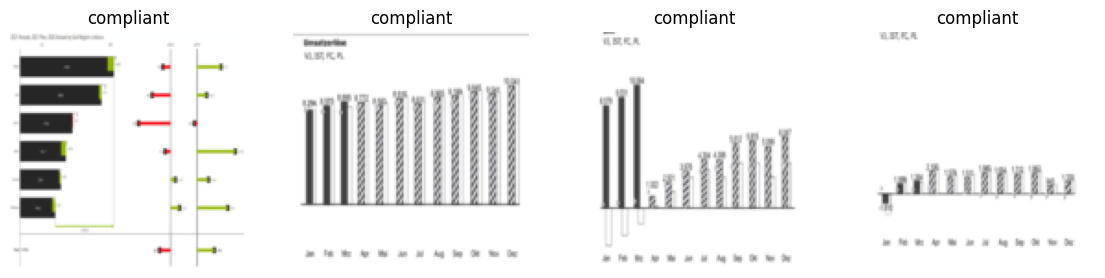

In [168]:

label_names = {1: "compliant", 0: "non-compliant"}

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for i in range(4):
    image, label = dataset[i]
    axes[i].imshow(image.permute(1, 2, 0))
    axes[i].set_title(label_names[int(label.item())])
    axes[i].axis("off")
plt.show()



## 6. Define a very simple CNN

This model is much easier to understand than ResNet:
- 2 convolution blocks
- flatten
- 2 linear layers
- 1 output for binary classification


In [169]:
# Load pretrained ResNet (ImageNet weights)
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Replace final layer for binary classification
model.fc = nn.Linear(model.fc.in_features, 1)

model = model.to(DEVICE)

## 7. Loss function and optimizer

In [170]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)



This is the loss function it checks how big the error is from the prediction
The model needs this since its essentialy just guessing each time. With the loss function we can check how good/bad those guesses are.
With the optimizer we can adjust the guesses with weights to eventually find the best model.

The optimizer allows the model to keep changing all its weights. 
So the model can eventually find the best weight values for the model for predictions.



Why `BCEWithLogitsLoss`?

- It is the standard choice for binary classification.
- The model outputs a raw score.
- We convert that score to a probability with `torch.sigmoid()` only when needed.


## 8. Evaluation function

In [171]:

def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probabilities = torch.sigmoid(outputs)
            predictions = (probabilities >= 0.5).float()

            total_loss += loss.item()
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy


## 9. Training loop

In [180]:

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
}

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        probabilities = torch.sigmoid(outputs)
        predictions = (probabilities >= 0.5).float()

        running_loss += loss.item()
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    val_loss, val_acc = evaluate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}")
    print("-" * 40)


Epoch 1/10
Train Loss: 0.0633 | Train Acc: 0.96
Val Loss:   0.0599 | Val Acc:   1.00
----------------------------------------
Epoch 2/10
Train Loss: 0.1369 | Train Acc: 0.96
Val Loss:   0.0264 | Val Acc:   1.00
----------------------------------------
Epoch 3/10
Train Loss: 0.4958 | Train Acc: 0.96
Val Loss:   0.1180 | Val Acc:   0.88
----------------------------------------
Epoch 4/10
Train Loss: 0.3934 | Train Acc: 0.85
Val Loss:   1.1153 | Val Acc:   0.62
----------------------------------------
Epoch 5/10
Train Loss: 0.2402 | Train Acc: 0.88
Val Loss:   0.1861 | Val Acc:   0.88
----------------------------------------
Epoch 6/10
Train Loss: 0.3693 | Train Acc: 0.92
Val Loss:   0.0518 | Val Acc:   1.00
----------------------------------------
Epoch 7/10
Train Loss: 0.2217 | Train Acc: 0.92
Val Loss:   0.0714 | Val Acc:   1.00
----------------------------------------
Epoch 8/10
Train Loss: 0.0430 | Train Acc: 0.96
Val Loss:   0.0612 | Val Acc:   1.00
---------------------------------

In the training and validation results. We see a clear pattern with the more epochs we run.
The lower the training loss becomes but the higher the validation loss becomes.
This is a classic overfitting identifier. The model is learning and remembering with each epoch the small dataset.
Hereby it gets worse at generalizing which you can see in the validation loss. 
As it increases over each epoch it gets better at detecting already seen images. And gets worse at never seen images.

High validation losses don't necesarilly have to be bad. Since they're just a sum of the losses of each image.
A high loss can suggest the model is very confident when a prediction is wrong.

Possible fixes are. We see in the first couple of epochs (until 5) the model is still quite stable. So instead of running it 10 times, a better value could be 5. 

## 10. Plot learning curves

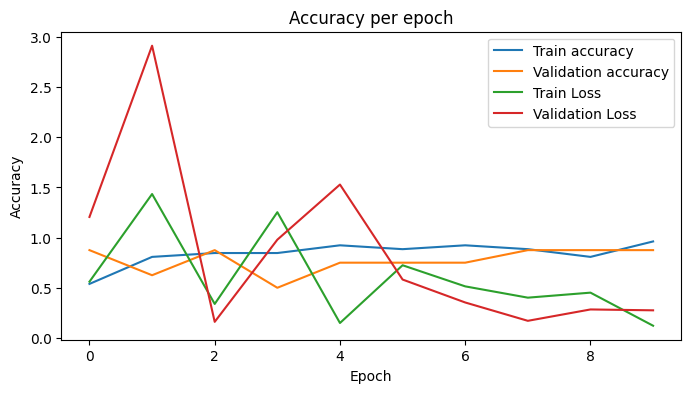

In [173]:

plt.figure(figsize=(8, 4))
plt.plot(history["train_acc"], label="Train accuracy")
plt.plot(history["val_acc"], label="Validation accuracy")
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy per epoch")
plt.legend()
plt.show()


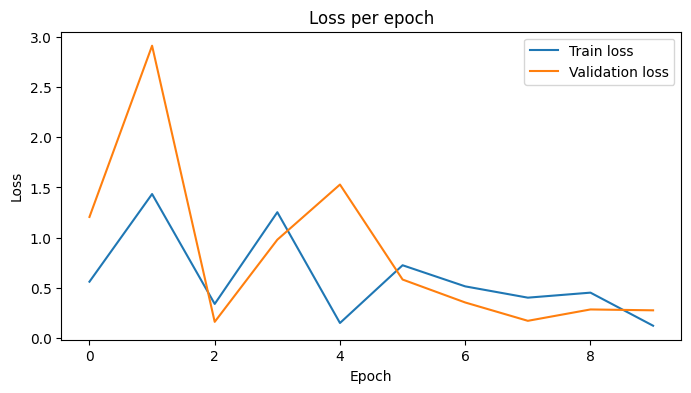

In [174]:

plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="Train loss")
plt.plot(history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss per epoch")
plt.legend()
plt.show()


## 11. Final test accuracy

In [175]:

test_loss, test_acc = evaluate(model, test_loader)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}")


Test Loss: 0.6096
Test Accuracy: 0.67


## 12. Predict one image

In [176]:

def predict_image(image_path):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = model(image_tensor)
        probability = torch.sigmoid(output).item()

    prediction = 1 if probability >= 0.5 else 0
    label_name = "compliant" if prediction == 1 else "non-compliant"

    return {
        "prediction": prediction,
        "label_name": label_name,
        "probability_compliant": probability,
    }



Example:
```python
result = predict_image("../images_data/compliant/example.png")

print(result)
```


## 13. Save the trained model

In [177]:

torch.save({
    "model_state_dict": model.state_dict(),
    "img_size": IMG_SIZE,
    "threshold": 0.5,
}, "jugo_simple_model.pth")

print("Model saved as jugo_simple_model.pth")


Model saved as jugo_simple_model.pth



## Notes

Keep this version as your **baseline model**.

Only add more complexity later if this simple model works and you can clearly explain why you need more.
